Tutorial from: [link](https://github.com/dylkot/cNMF/blob/main/Tutorials/analyze_pbmc_example_data.ipynb)

# Hyperparameters

In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from scipy import sparse
import scanpy as sc
import matplotlib.pyplot as plt
import os
import rpy2.robjects as ro
from cnmf import cNMF
import h5py
from sklearn.preprocessing import normalize
import subprocess
from multiprocessing import Process
from sklearn.decomposition import non_negative_factorization


from dotenv import load_dotenv; load_dotenv()


from utils import preprocessing
from utils import DEG

# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline

PARALLEL_NEBULA_SCRIPT_PATH = os.getenv("PARALLEL_NEBULA_SCRIPT")

DATASET_FOLDER = "/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions"
TRUE_DEG_PATH = f"{DATASET_FOLDER}/../genes.csv"
QS_TMP_FOLDER = "/home/gdallagl/myworkdir/XDP/data/_old/nebula_tmp" # tmp folder where to save intemrediate results
METHOD_NAME = "cNMF_nebula"
FOLDER_FOR_HEALTHY_ADATA = "/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/all_samples"

# name of cell tyoe vauble annotaton to use in this analsys
CT_FOR_DEG_VARIABLE = "spn_type" #"Group_name",  "spn_type"
# name of Sample varibale
SAMPLE_VARIABLE = "donor_id"
# variable to test if differtially epxressed
CONTRAST_VARIABLE = "case_control"
# Level of contrat varibale to use as baseline
CONTRAST_BASELINE = "control"
# Level of contrat varibale to use as stimulated
CONTRAST_STIM = "case"

# Covariates to use for stat test
COVARIATES_FOR_DEG = ["Age.at.Death", "Sex", "PMI", "pct_mt", "pct_intronic",
                      ]
# libraru size col for  enbula
LIBRARY_SIZE_COL = "nCount_RNA"

# mitluple etst correction pvalue thr
ALPHA_MULTIPLE_TEST = 0.05
LOGFC_THR=0.1
PVAL_THR=0.05


#NMF
N_WORKERS = 30
N_NMFs = 5
N_NMFs_TO_TEST = np.arange(5, 6)
N_ITERS=25

# Create Covs and update .qs File

Each method will add its covaritates in .qs obj (needed for Nebula).


After running 50 NMF iterations for K=10:
You have 50 different sets of 10 programs (500 total programs)

cnmf.consensus(k=10, density_threshold=0.01)

 This:
1. Clusters the 500 programs into 10 consensus clusters
2. Filters outliers (using density_threshold)
3. Averages programs in each cluster → final 10 programs

For each NMF iteration, cNMF calculates:
- Distance to its K nearest neighbors (other iterations)
- If mean distance > threshold → it's an outlier → REMOVE

# Create Only heathy h5ad

In [ ]:
# Whichever dataset works (seubsetting to only healhty)
dataset = sorted(os.listdir(DATASET_FOLDER))[0]

dataset_path_h5ad = os.path.join(DATASET_FOLDER, dataset, f"{dataset}.h5ad")
dataset_path_healthy = os.path.join(results_folder, f"{dataset}_healthy.h5ad")



## Run cNMF on Healthy (same for all dataset)

same for all:
- depletion
- gene pertubrations
(healthy split always the same)

In [2]:
def run_cnmf_worker(results_folder, worker_i, total_workers):
    """
    Worker function that will run in parallel
    Each worker runs a subset of NMF iterations
    """
    cnmf_obj = cNMF(
        output_dir=f"{results_folder}/cnmf_healthy", 
        name='healthy_model'
    )
    cnmf_obj.factorize(worker_i=worker_i, total_workers=total_workers)
    print(f"✓ Worker {worker_i}/{total_workers} finished!")

In [ ]:
# Whichever dataset works (seubsetting to only healhty)
dataset  = sorted(os.listdir(DATASET_FOLDER))[0]

# Save paths
results_folder = os.path.join(DATASET_FOLDER, dataset, METHOD_NAME)
dataset_path_h5ad = os.path.join(DATASET_FOLDER, dataset, f"{dataset}.h5ad")
dataset_path_qs = os.path.join(DATASET_FOLDER, dataset, f"{dataset}.qs")
cov_df_csv_path = os.path.join(results_folder, "covariates_df.csv")
dataset_path_healthy = os.path.join(results_folder, f"{dataset}_healthy.h5ad")
os.makedirs(results_folder, exist_ok=True)

# Save healthy cells only
print("Loading dataset...")
adata_tmp = sc.read_h5ad(dataset_path_h5ad)
print(f"Saving healthy cells to {dataset_path_healthy}...")
adata_tmp[adata_tmp.obs[CONTRAST_VARIABLE] == CONTRAST_BASELINE].copy().write(dataset_path_healthy)

# Initialize cNMF for healthy training
print("Preparing cNMF...")
cnmf_healthy = cNMF(output_dir=f"{results_folder}/cnmf_healthy", name='healthy_model')

# Prepare - this step:
# - Selects HVGs
# - Normalizes to TPM
# - Saves preprocessed data
cnmf_healthy.prepare(
    counts_fn=dataset_path_healthy,  # Healthy cells only
    components=N_NMFs_TO_TEST,  # Test k=8,9,10,...,15
    n_iter=N_ITERS,  # 100 iterations for robustness
    seed=42,
    num_highvar_genes=3000  # Select 2000 HVGs
)

# Factorize - run NMF
# For parallel: use --total-workers and --worker-index
#cnmf_healthy.factorize(worker_i=0, total_workers=16)

print(f"\nStarting {N_WORKERS} parallel workers for factorization...")
# Launch all workers
processes = []
for worker_i in range(N_WORKERS):
    p = Process(
        target=run_cnmf_worker,
        args=(results_folder, worker_i, N_WORKERS)
    )
    p.start()
    processes.append(p)
    print(f"   Started worker {worker_i}/{N_WORKERS}")
# Wait for ALL workers to finish
for i, p in enumerate(processes):
    p.join()
    print(f"   Worker {i} completed")

print("✓ All workers finished!\n")

# Combine results from all iterations
print("Combining NMF results...")
cnmf_healthy.combine()

# K selection plot - helps choose best K
print("Generating K selection plot...")
cnmf_healthy.k_selection_plot()

# Consensus step - choose K=10 based on plot
print(f"Running consensus (K={N_NMFs})...")
cnmf_healthy.consensus(k=N_NMFs, density_threshold=0.01)

# Calute/Project for all datasets


######
 Processing dataset: depleted_0.00_dorsal_matrix 
######

Loading dataset...
Saving healthy cells to /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions/depleted_0.00_dorsal_matrix/cNMF_nebula/depleted_0.00_dorsal_matrix_healthy.h5ad...
Preparing cNMF...

Starting 30 parallel workers for factorization...


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/cnmf/cnmf.py:616: UserWarning: 25 runs already appear completed. If this is unexpected, consider
            re-initializing the cnmf object with a different run name or output directory
  warnings.warn(message, UserWarning)


   Started worker 0/30
   Started worker 1/30
   Started worker 2/30
   Started worker 3/30
   Started worker 4/30
   Started worker 5/30
   Started worker 6/30
   Started worker 7/30
   Started worker 8/30
   Started worker 9/30
   Started worker 10/30
   Started worker 11/30
   Started worker 12/30
   Started worker 13/30
   Started worker 14/30
   Started worker 15/30
   Started worker 16/30
   Started worker 17/30
   Started worker 18/30
   Started worker 19/30
   Started worker 20/30
   Started worker 21/30
   Started worker 22/30
   Started worker 23/30
   Started worker 24/30
   Started worker 25/30
   Started worker 26/30
   Started worker 27/30
   Started worker 28/30
   Started worker 29/30
[Worker 0]. Starting task 0.
[Worker 1]. Starting task 1.[Worker 2]. Starting task 2.

[Worker 3]. Starting task 3.
[Worker 7]. Starting task 7.
[Worker 9]. Starting task 9.
[Worker 10]. Starting task 10.[Worker 8]. Starting task 8.

[Worker 11]. Starting task 11.[Worker 12]. Starting task

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Loading NMF results...
Transposed spectra to: (5, 37905)
Normalizing all cells to TPM...
Genes in spectra: 37905
Genes in dataset: 37905
Matching genes: 37905
Saving covariates to /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions/depleted_0.00_dorsal_matrix/cNMF_nebula/covariates_df.csv...
✓ Saved covariates: (121633, 6)


...

Mean reconstruction error: 4752.952768


Updating .qs file...
[1] "Reading obj..."


2026-02-03 13:19:37 | [WARNING] R callback write-console: Loading required namespace: SeuratObject
  


[1] "Saving..."


2026-02-03 13:20:05 | [WARNING] R callback write-console: In addition:   
2026-02-03 13:20:05 | [WARNING] R callback write-console: Warning message:
  
2026-02-03 13:20:05 | [WARNING] R callback write-console: In merge.data.frame(sc_obj@meta.data, new_meta, by.x = "row.names",  :  
2026-02-03 13:20:05 | [WARNING] R callback write-console: 
   
2026-02-03 13:20:05 | [WARNING] R callback write-console:  column name ‘Row.names’ is duplicated in the result
  


✓ Dataset 'depleted_0.00_dorsal_matrix' complete!



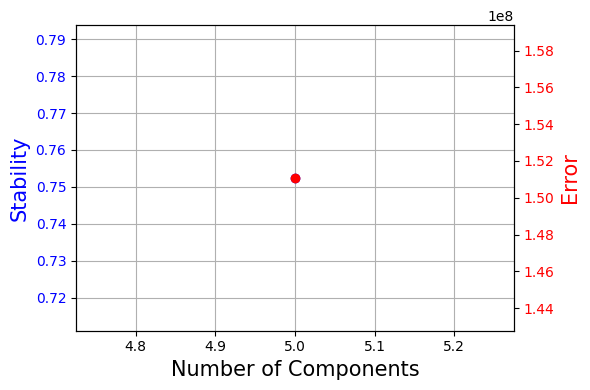

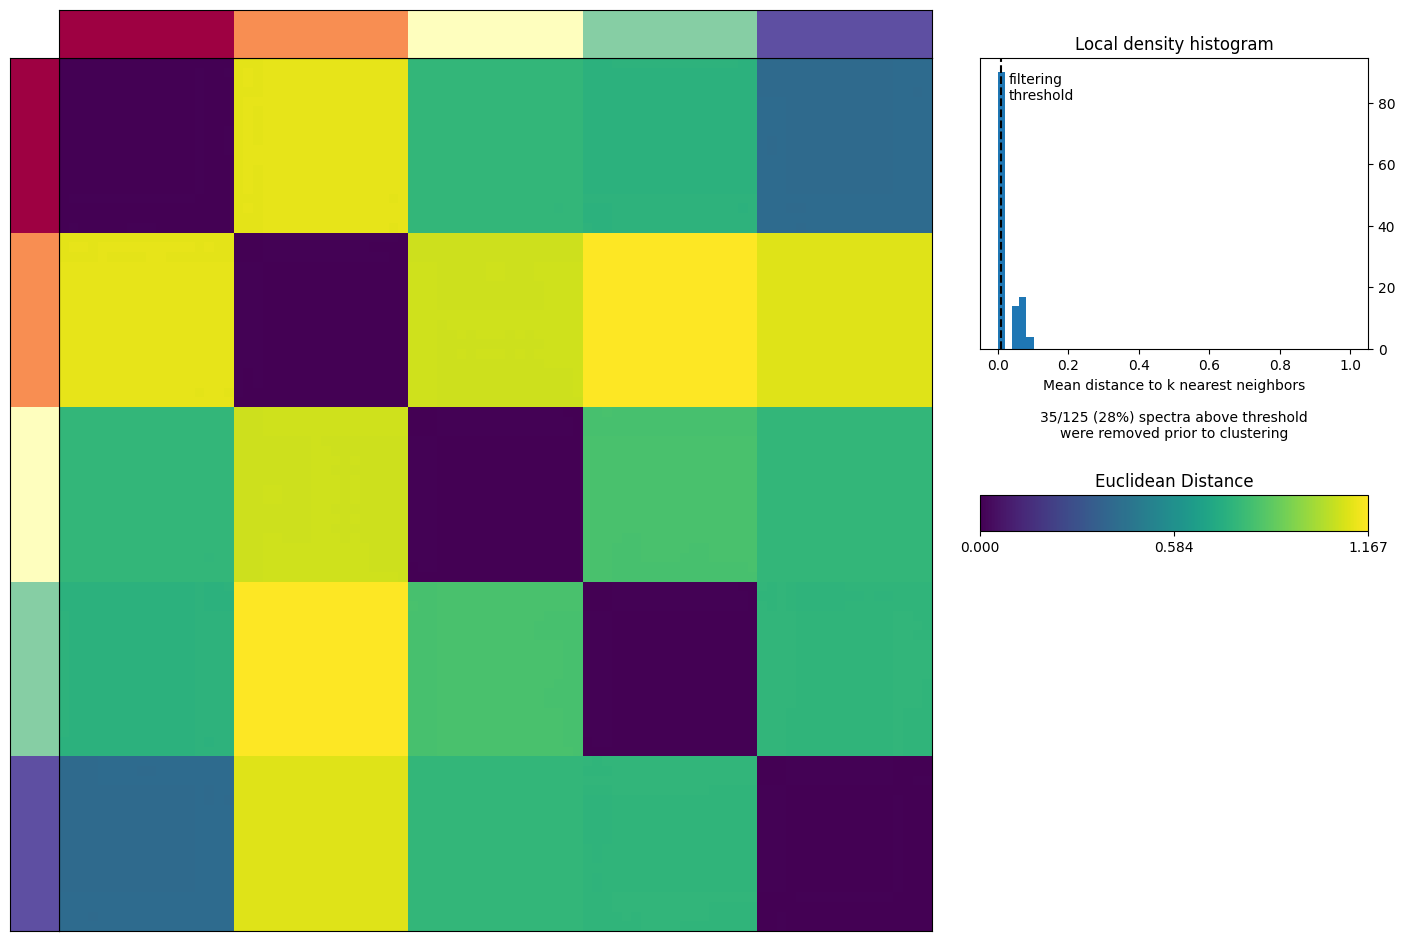

In [ ]:
for dataset in sorted(os.listdir(DATASET_FOLDER)):

    print(f"\n######\n Processing dataset: {dataset} \n######\n")

    results_folder = os.path.join(DATASET_FOLDER, dataset, METHOD_NAME)
    dataset_path_h5ad = os.path.join(DATASET_FOLDER, dataset, f"{dataset}.h5ad")
    dataset_path_qs = os.path.join(DATASET_FOLDER, dataset, f"{dataset}.qs")
    cov_df_csv_path = os.path.join(results_folder, "covariates_df.csv")
    dataset_path_healthy = os.path.join(results_folder, f"{dataset}_healthy.h5ad")
    os.makedirs(results_folder, exist_ok=True)

    ###################

    # Logic to calcualte specific Covs --> df with covariates (cov_df_csv_path)

    # Save healthy cells only
    print("Loading dataset...")
    adata_tmp = sc.read_h5ad(dataset_path_h5ad)
    print(f"Saving healthy cells to {dataset_path_healthy}...")
    adata_tmp[adata_tmp.obs[CONTRAST_VARIABLE] == CONTRAST_BASELINE].copy().write(dataset_path_healthy)

    # Initialize cNMF for healthy training
    print("Preparing cNMF...")
    cnmf_healthy = cNMF(output_dir=f"{results_folder}/cnmf_healthy", name='healthy_model')

    # Prepare - this step:
    # - Selects HVGs
    # - Normalizes to TPM
    # - Saves preprocessed data
    cnmf_healthy.prepare(
        counts_fn=dataset_path_healthy,  # Healthy cells only
        components=N_NMFs_TO_TEST,  # Test k=8,9,10,...,15
        n_iter=N_ITERS,  # 100 iterations for robustness
        seed=42,
        num_highvar_genes=3000  # Select 2000 HVGs
    )

    # Factorize - run NMF
    # For parallel: use --total-workers and --worker-index
    #cnmf_healthy.factorize(worker_i=0, total_workers=16)
    
    print(f"\nStarting {N_WORKERS} parallel workers for factorization...")
    # Launch all workers
    processes = []
    for worker_i in range(N_WORKERS):
        p = Process(
            target=run_cnmf_worker,
            args=(results_folder, worker_i, N_WORKERS)
        )
        p.start()
        processes.append(p)
        print(f"   Started worker {worker_i}/{N_WORKERS}")
    # Wait for ALL workers to finish
    for i, p in enumerate(processes):
        p.join()
        print(f"   Worker {i} completed")
    
    print("✓ All workers finished!\n")

    # Combine results from all iterations
    print("Combining NMF results...")
    cnmf_healthy.combine()

    # K selection plot - helps choose best K
    print("Generating K selection plot...")
    cnmf_healthy.k_selection_plot()

    # Consensus step - choose K=10 based on plot
    print(f"Running consensus (K={N_NMFs})...")
    cnmf_healthy.consensus(k=N_NMFs, density_threshold=0.01)



    

    # Load the gene expression programs learned from healthy
        # usage: (N_cells × K) - how much each cell uses each program (from healthy only)
        # spectra_scores: (K × G) - gene scores (Z-scores)
        # spectra_tpm: (K × G) - gene programs in TPM units ← You use this for projection!
        # top_genes: List of top 100 genes per program
    print("Loading NMF results...")
    usage_healthy, spectra_scores, spectra_tpm, top_genes = cnmf_healthy.load_results(
        K=N_NMFs, 
        density_threshold=0.01
    )

    # Gene names are in the INDEX, programs in columns
    # Need to transpose to get (K, G) format
    if spectra_tpm.shape[1] == N_NMFs and spectra_tpm.shape[0] > N_NMFs:
        spectra_tpm = spectra_tpm.T
        print(f"Transposed spectra to: {spectra_tpm.shape}")

    # Load the HVGs that cNMF selected
    hvgs = np.loadtxt(f'{results_folder}/cnmf_healthy/healthy_model/healthy_model.overdispersed_genes.txt', dtype=str)

    # # Load the TPM-normalized matrix that cNMF created
    # tpm_file = f'{results_folder}/cnmf_healthy/healthy_model/cnmf_tmp/healthy_model.tpm.h5ad'
    # adata_tpm = sc.read_h5ad(tpm_file)

    # Normalize all cells to TPM (same as cNMF does)
    print("Normalizing all cells to TPM...")
    sc.pp.normalize_total(adata_tmp, target_sum=1e6)

    # Match genes
    gene_names_in_spectra = list(spectra_tpm.columns)
    genes_common = set(gene_names_in_spectra) & set(adata_tmp.var_names)
    hvgs_present = [g for g in gene_names_in_spectra if g in genes_common]

    print(f"Genes in spectra: {len(gene_names_in_spectra)}")
    print(f"Genes in dataset: {adata_tmp.n_vars}")
    print(f"Matching genes: {len(hvgs_present)}")

    # Get TPM matrix for matching genes
    X_tpm = adata_tmp[:, hvgs_present].X
    if hasattr(X_tpm, 'toarray'):
        X_tpm = X_tpm.toarray()

    # Subset spectra to matching genes
    spectra_subset = spectra_tpm[hvgs_present].values  # (K × G_matched)

    # Project using learned gene programs
    #usage_all_raw = X_hvg_all @ spectra_tpm_subset.T # --> APPROXIMATION
    usage_all_raw, _, n_iter = non_negative_factorization(
        X_tpm,
        n_components=N_NMFs,
        H=spectra_subset,        # Fixed gene programs
        update_H=False,          # Don't update spectra
        init='random',
        random_state=0,
        max_iter=1000
    )

    # Normalize so each cell sums to 1 (standard for usage matrix)
    usage_all = normalize(usage_all_raw, norm='l1', axis=1)

    # add to adata
    for i in range(N_NMFs):
        adata_tmp.obs[f'NMF_{i}'] = usage_all[:, i]

    # save df
    print(f"Saving covariates to {cov_df_csv_path}...")
    nmf_df = pd.DataFrame({
        'barcode': adata_tmp.obs_names.tolist()  # Cell barcodes
    })
    for i in range(N_NMFs):
        nmf_df[f'NMF_{i}'] = usage_all[:, i]
    nmf_df.to_csv(cov_df_csv_path, index=False)
    print(f"✓ Saved covariates: {nmf_df.shape}")

    # Check reconstruction error
    X_reconstructed = usage_all @ spectra_subset
    reconstruction_error = np.mean((X_tpm - X_reconstructed)**2)
    print(f"Mean reconstruction error: {reconstruction_error:.6f}")

    ##################

    # Update obs of .qs obj
    print(f"\n\nUpdating .qs file...")
    preprocessing.add_metadata_to_qs(
        base_qs_path=dataset_path_qs,
        new_metadata_df_path=cov_df_csv_path,
        barcode_col="barcode",
    )
    print(f"✓ Dataset '{dataset}' complete!\n")


    break

# *) Investigation


In [7]:
# Get top genes from cNMF results
    # Top 100 genes per program (sorted by importance)
display(top_genes.iloc[:20,:])

nmf_df

,1,2,3,4,5
0,CHRM3,ARL17B,CNR1,PRKG1,CALM1
1,DRD2,WIPF3,HS6ST3,ROBO1,ARPP19
2,PTPRM,ENSG00000224363,ERBB4,ERC2,CTXN1
3,FIG4,CCDC144A,EBF1,CDH12,HSP90AB1
4,OPRD1,STXBP5L,GALNT18,HCN1,THY1
5,FAM135B,ITFG1,ROBO2,GALNTL6,NORAD
6,PRKD1,PLEKHA5,FOXP2,CADM1,PPP1R1B
7,RBMS1,ANKRD30BL,GPAT2,PDE1C,CALM3
8,KCNK2,FAM27C,STUM,RGS6,VAMP2
9,CDH6,ZNF37A,SOX1-OT,ARHGAP6,GAPDH


,barcode,NMF_0,NMF_1,NMF_2,NMF_3,NMF_4
0,STR_D1_Matrix_MSN_s5_s5_AACAGGAGTGCACGTA_1,0.000000,0.000000,0.640571,0.359429,0.000000
1,STR_D1_Matrix_MSN_s5_s5_ACATTGGTCGGGTATC_1,0.027381,0.000000,0.384738,0.587882,0.000000
2,STR_D1_Matrix_MSN_s5_s5_ATTGCATAGACCAATT_1,0.018537,0.000000,0.341880,0.626492,0.013092
3,STR_D1_Matrix_MSN_s5_s5_CGGATATGTCTCGATC_1,0.000000,0.000000,0.523761,0.476239,0.000000
4,STR_D1_Matrix_MSN_s5_s5_ACCATTCTCCAGTATG_1,0.000000,0.000000,0.543333,0.456667,0.000000
...,...,...,...,...,...,...
121628,s38_2025-06-04_s38_GEX_CAP_rxn4_AGTCCGGTCCGACTAA,0.140043,0.292360,0.000000,0.428587,0.139009
121629,s38_2025-06-04_s38_GEX_CAP_rxn4_ACATAGAAGATATTGC,0.364452,0.206038,0.000000,0.426034,0.003476
121630,s38_2025-06-04_s38_GEX_CAP_rxn4_CGTTTCAGTCTGTATT,0.279165,0.087855,0.216146,0.260072,0.156761
121631,s38_2025-06-04_s38_GEX_CAP_rxn4_ACGTCCGAGCTGGCAT,0.013759,0.299804,0.182954,0.481605,0.021878


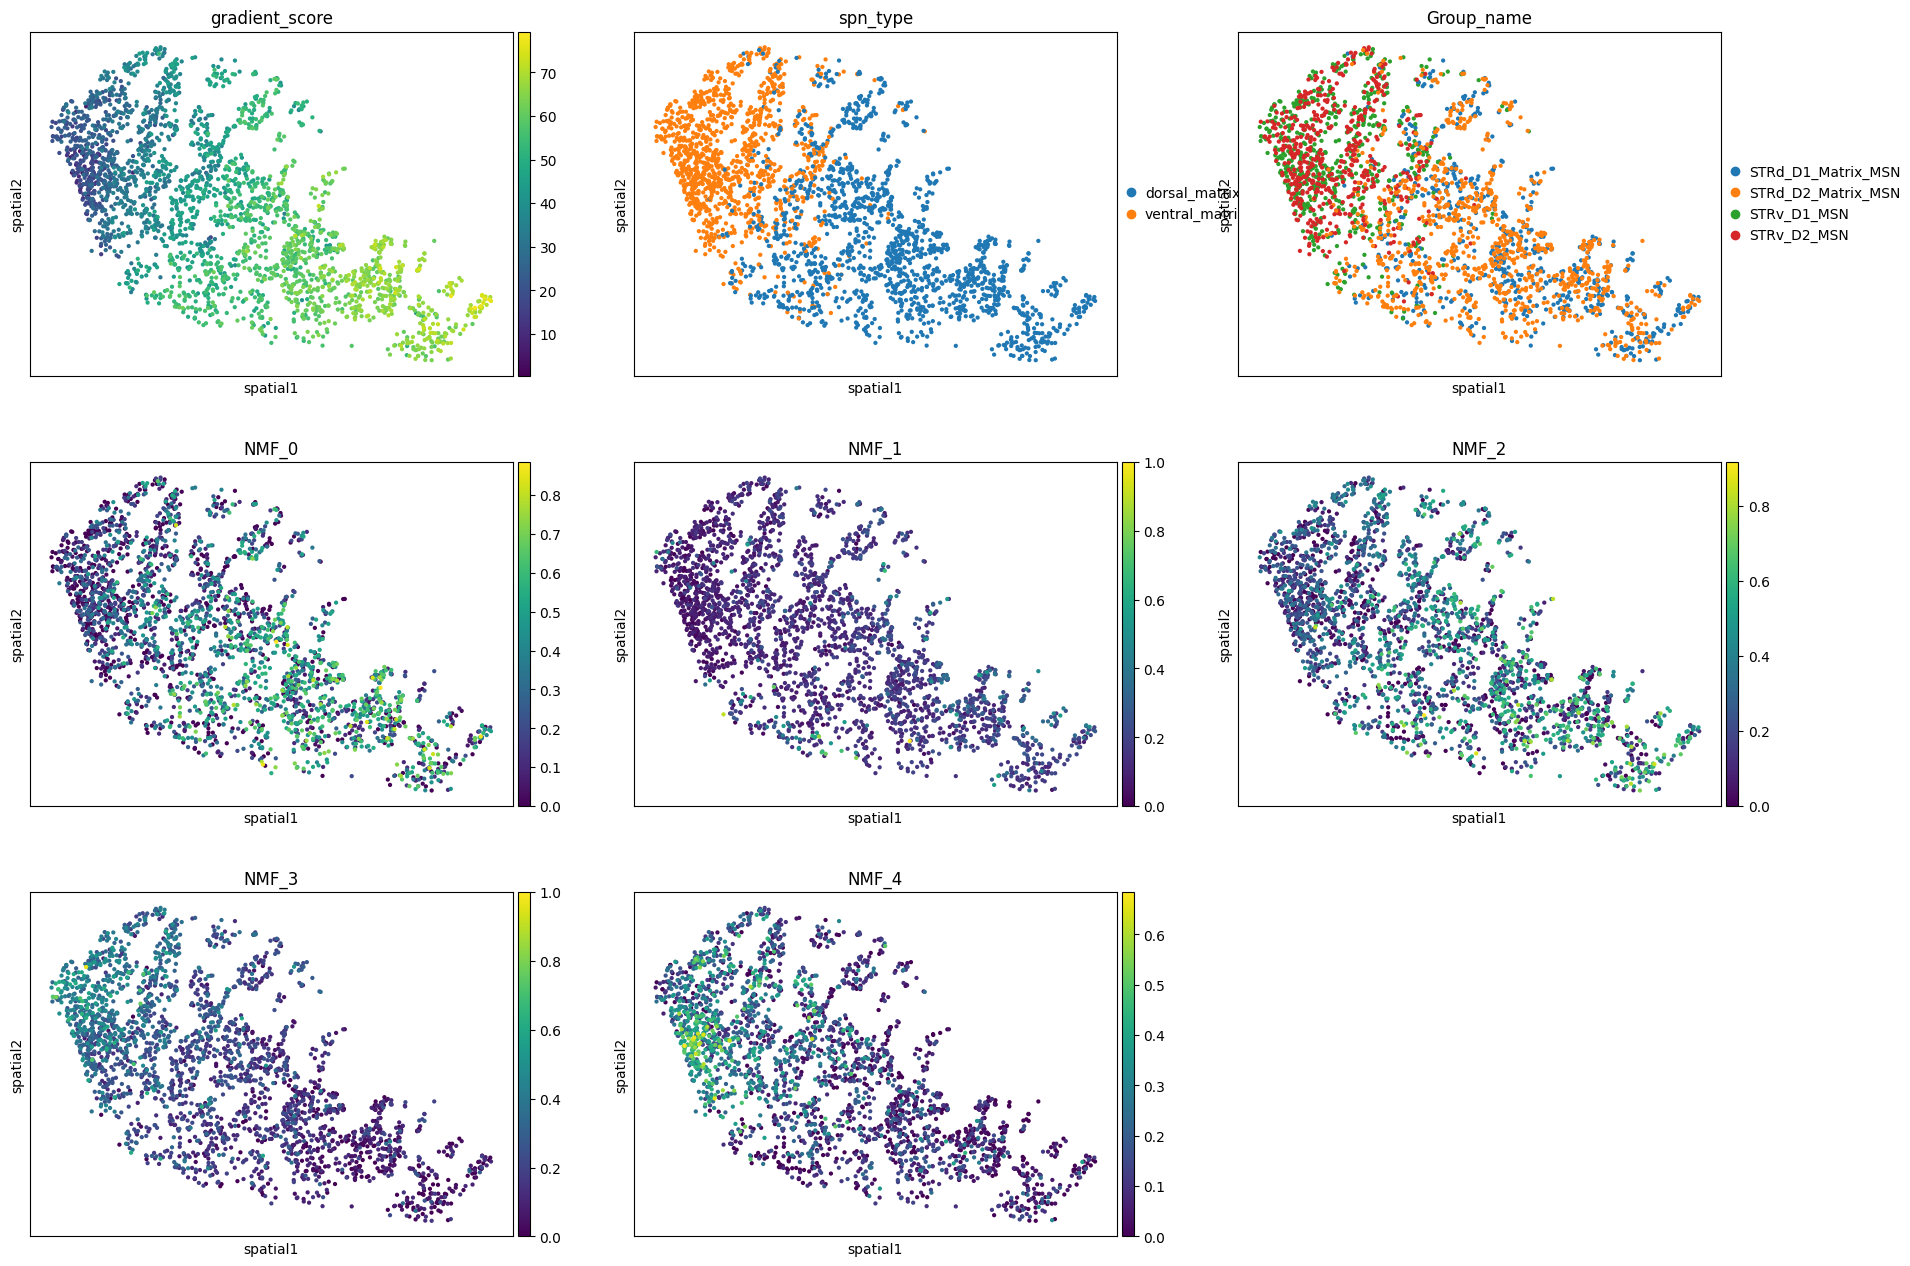

In [8]:
sample_id = "MS913848" #adata_pert_tmp.obs[adata_pert_tmp.obs[CONTRAST_VARIABLE] == CONTRAST_VARIABLE_DISEASED][DONOR_ID_VARIABLE].unique()[0]
adata_s = adata_tmp[adata_tmp.obs[SAMPLE_VARIABLE] == sample_id].to_memory().copy()
adata_s.obsm["spatial"] = adata_s.obs[["x", "y"]].values  # or .to_numpy()
nmfs = [i for i in adata_s.obs.columns if "NMF_" in i]
sc.pl.embedding(adata_s, basis="spatial", color=["gradient_score", "spn_type", "Group_name", *nmfs], ncols=3)
#del adata_s

# DEG

In [4]:
for dataset in sorted(os.listdir(DATASET_FOLDER)):

    #dataset="depleted_0.05_dorsal_matrix"

    print(f"\n######\n Processing dataset: {dataset} \n######\n")

    results_folder = os.path.join(DATASET_FOLDER, dataset, METHOD_NAME)
    dataset_path_qs = os.path.join(DATASET_FOLDER, dataset, f"{dataset}.qs")
    save_csv_path = os.path.join(results_folder, f"{dataset}-{METHOD_NAME}_results.csv")
    print(save_csv_path)

    # NMFs
    nmfs = [f"NMF_{i}" for i in range(0, N_NMFs)]

    # Run Nebula
    nebula_result_path = DEG.run_nebula_parallel_script(
        path_qs = dataset_path_qs,
        path_nebula_script = PARALLEL_NEBULA_SCRIPT_PATH,
        id_col = SAMPLE_VARIABLE,
        covs = [CONTRAST_VARIABLE, *COVARIATES_FOR_DEG, *nmfs], # wihtout LIBRARY_SIZE_COL, with constrst vaibale too
        offset_col = LIBRARY_SIZE_COL,
        n_folds = 20, # (MORE gene chunks = LESS RAM per chunk)
        n_cores = 10, # (FEWER parallel jobs = LESS total RAM)
        save_tmp = False,
        suffix = None,
    )

    # save csv
    ro.r(f'''
        library(qs)
        obj <- qread("{nebula_result_path}")
        df <- obj$summary
        write.csv(df, "{save_csv_path}", row.names = FALSE)
    ''')

    break

    


######
 Processing dataset: depleted_0.00_dorsal_matrix 
######

/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions/depleted_0.00_dorsal_matrix/cNMF_nebula/depleted_0.00_dorsal_matrix-cNMF_nebula_results.csv
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions/depleted_0.00_dorsal_matrix/depleted_0.00_dorsal_matrix.qs --id-col donor_id --offset-col nCount_RNA --n-folds 20 --n-cores 10 --save-tmp 0 --covs case_control,Age.at.Death,Sex,PMI,pct_mt,pct_intronic,NMF_0,NMF_1,NMF_2,NMF_3,NMF_4


2026-02-03 16:29:52 | [WARNING] R callback write-console: qs 0.27.3. Announcement: https://github.com/qsbase/qs/issues/103
  


STDOUT:
[INFO] Input: /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions/depleted_0.00_dorsal_matrix/depleted_0.00_dorsal_matrix.qs
[INFO] Script dir: /home/gdallagl/myworkdir/XDP/utils/nebula_scripts
[INFO] Base name: depleted_0.00_dorsal_matrix.qs
[INFO] Geneset dir: /home/gdallagl/myworkdir/data/XDP/artificial_bican/geneset_001/depleted_versions/depleted_0.00_dorsal_matrix
[INFO] Geneset: depleted_0.00_dorsal_matrix
[INFO] Split dir: /home/gdallagl/myworkdir/data/XDP/artificial_bican/geneset_001/depleted_versions
[INFO] Split: depleted_versions
[INFO] n-folds: 20
[INFO] parallel jobs: 10
[INFO] id-col: donor_id
[INFO] covs:
       - case_control
       - Age.at.Death
       - Sex
       - PMI
       - pct_mt
       - pct_intronic
       - NMF_0
       - NMF_1
       - NMF_2
       - NMF_3
       - NMF_4
[INFO] offset-col: nCount_RNA  -> will create meta 'nUMI_nebula'
[INFO] Tmp dir: /home/gdallagl/myworkdir/data/XDP/artificial_bican/geneset_001/depl

# Plot Results

In [5]:
df_true_degs = pd.read_csv(TRUE_DEG_PATH)
df_true_degs


,gene_id,log2fc,frac_applied,n_subjects_applied,subjects_applied
0,ENSG00000237280,0.522222,0.3,3,"MD9129,MS986638,UMBEB23076"
1,ENSG00000250027,0.733333,0.7,7,"MD9129,MS30499,MS706984,MS876075,MS986638,UMBE..."
2,ENSG00000289321,-0.733333,0.4,4,"MD6927,MS30499,MS876075,MS986638"
3,OTULIN,0.100000,0.6,6,"MD6927,MD9129,MS30499,MS876075,MS986638,UMBEB2..."
4,MYLIP,-0.522222,0.2,2,"MD6927,UMBEB22074"
...,...,...,...,...,...
395,FLVCR2,0.733333,0.1,1,UMBEB23158
396,PTPN20,1.577778,0.5,5,"MD6927,MS30499,MS706984,UMBEB22074,UMBEB23158"
397,RACGAP1,-0.100000,0.7,7,"MD6927,MD9129,MS30499,UMBEB22074,UMBEB23076,UM..."
398,ENSG00000257239,2.000000,0.5,5,"MS706984,MS876075,MS986638,UMBEB23076,UMBEB24013"



######
 Processing dataset: depleted_0.00_dorsal_matrix 
######



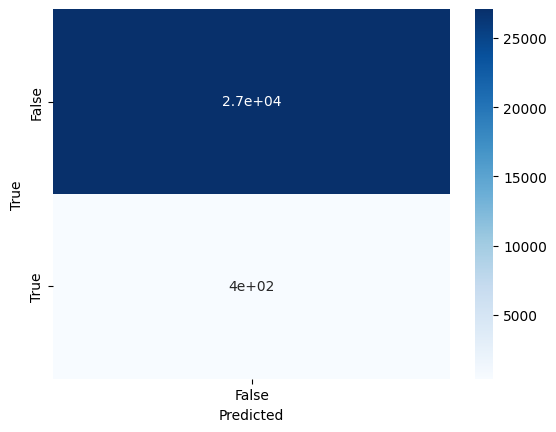

Precision: 0.000
Recall:    0.000
F1 Score:  0.000
Accuracy:  0.985


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gdallagl/myworkdir/XDP/utils/DEG.py:741: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', frameon=False)


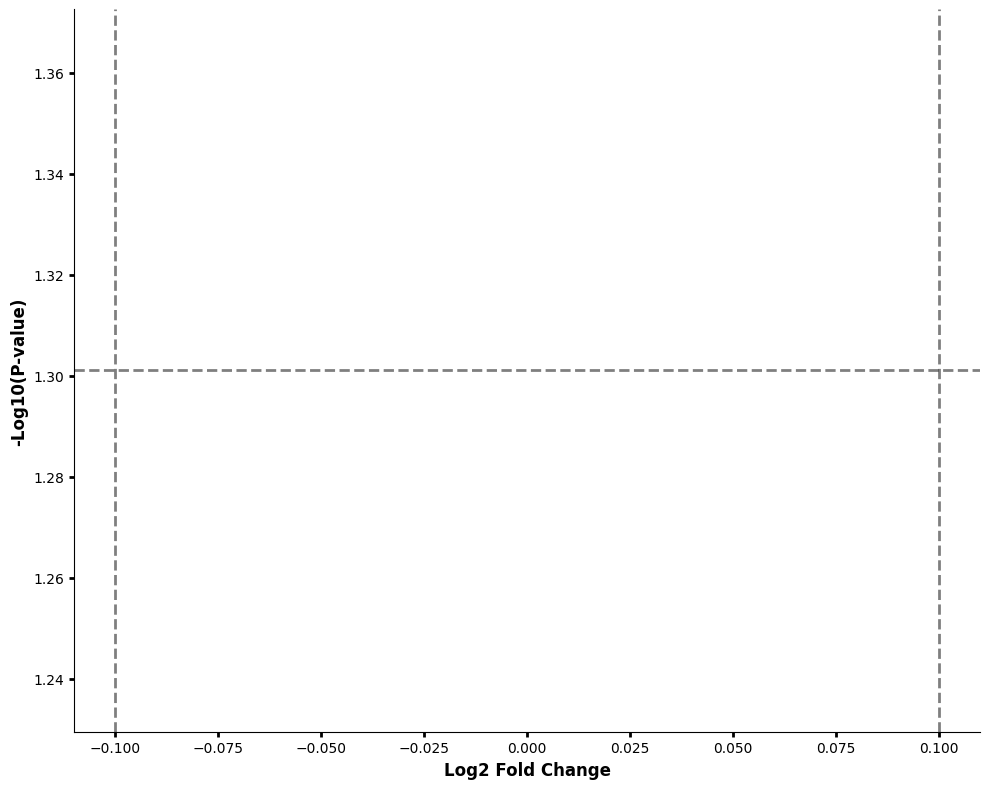

,gene,logFC_case_controlcase,p_case_controlcase,adj_p_case_controlcase,is_significant,is_true_DEG,-log10p,category,sorter


In [6]:
for dataset in sorted(os.listdir(DATASET_FOLDER)):

    print(f"\n######\n Processing dataset: {dataset} \n######\n")

    results_folder = os.path.join(DATASET_FOLDER, dataset, METHOD_NAME)
    save_csv_path = os.path.join(results_folder, f"{dataset}-{METHOD_NAME}_results.csv")

    df_nebula = pd.read_csv(save_csv_path)

    DEG.plot_nebula_results(df_nebula, 
                    df_true_degs, 
                    col_p=f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                    col_logFC=f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                    col_gene="gene",
                    PVAL_THR=PVAL_THR,
                    LOGFC_THR=LOGFC_THR,
                    max_FDR=10,
                    add_adj_p_col=True
                    )
    break

In [7]:
df_nebula

,logFC_(Intercept),logFC_case_controlcase,logFC_Age.at.Death,logFC_SexMale,logFC_PMI,logFC_pct_mt,logFC_pct_intronic,logFC_NMF_0,logFC_NMF_1,logFC_NMF_2,...,p_PMI,p_pct_mt,p_pct_intronic,p_NMF_0,p_NMF_1,p_NMF_2,p_NMF_3,p_NMF_4,gene_id,gene
0,-12.670550,-0.111604,0.005296,0.049503,-0.003587,-6.681588,-4.842009,51.060807,50.862951,51.043883,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,A1BG
1,-11.554594,-0.073887,0.003151,0.139821,0.003385,-2.881437,-1.889884,258.677451,259.453616,258.700390,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,A1BG-AS1
2,-15.364226,-0.234970,-0.003966,-0.093643,-0.034968,-17.882773,-3.877965,-7.023346,-7.426821,-6.927709,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,A1CF
3,-13.928860,0.278646,-0.002460,-0.162347,0.007976,5.688830,-0.850336,23.231235,21.216496,23.515120,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,A2M
4,-13.316394,0.036483,0.000684,0.045272,-0.007884,-1.650416,0.254674,16.853957,17.128563,16.996183,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,A2M-AS1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27476,-9.689872,-0.023050,0.001582,-0.054488,-0.003771,-0.939436,-0.042017,-8.131847,-8.345559,-8.164237,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,402,ZZEF1
27477,-9.131709,0.049910,0.000215,-0.091069,0.008052,-2.153107,0.552972,-10431.984833,-10432.310345,-10431.942192,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,403,ZZZ3
27478,-16.959808,0.427559,0.009265,0.657764,-0.013440,-26.319678,-2.570999,50.813721,50.678148,50.858511,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,419,ENSG00000205653
27479,-16.506802,-0.024461,0.007732,-0.282098,0.008230,12.094153,3.235531,1.277144,3.737309,1.372236,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1009,ENSG00000223438
